In [1]:
!git clone https://github.com/maheshreddykukunooru/Face_recognition.git
!mv Face_recognition/att_faces att_faces/ 

Cloning into 'Face_recognition'...
remote: Enumerating objects: 609, done.
remote: Total 609 (delta 0), reused 0 (delta 0), pack-reused 609
Receiving objects: 100% (609/609), 9.12 MiB | 29.95 MiB/s, done.
Resolving deltas: 100% (1/1), done.


# Principal Component Analysis:

PCA, is a dimensionality-reduction method that is used to represent data in smaller dimentions ,which are known as the principal components and still we preserve most of the information , we do so by finding directions that captures most of info or have large covariance and then based on how much data we want (99% or 95%) we project data on dimentions with large covariances.

### Prerequisite:

Before applying PCA data must be made zero centered

### Properties of Principle components:
1. Principle components are orthogonal to each other
2. Principle components with greater covariance holds most of the information amongst all principle components 


### How do we find Principle componnents:
1. So our goal is to find such principle components, using which if we reconstruct our data ,the reconstruction error is minimum 

$Error(X_{i}) = || X_{i} - (X_{i}.W).W^T ||^2 $

assume that $X_{i}$ is 1xN dimensional vector and W be matrix of top $k (k<N)$ principle components with dimension Nxk , $(X_{i}.W)$ is going to be of dimention 1xk (our reduced dimention space) and dimention of $(X_{i}.W).W^T$ is 1xN ,which basically is our reconstructed vector of X. and we want to minimise the distance beetween original vector and this reconstructed vector.

$Loss = \sum_{i=1}^{N} Error(X_{i})$


after using assumption that the principle component is going to be orthognal and of unit norm ,we can prove that minimising reconstruction error is equivalent to maximizing the variance of the projections (proof has been left as assignment).

since $X.W$ is our projection variance of projection will be :

$Variance_{projection} = \frac{1}{N} (X*W)^T*(X*W)$

$= \frac{1}{N} W^T*X^T*X*W$

$= W^T *(\frac{1}{N} X^T*X)*W$

$= W^T* Variance_{X}*W$

with constraint that $W^T*W=1$ we can introduce a Lagrange multiplier λ and do unconstrained optimization

$Loss(w,\lambda) = W^T* Variance_{X}*W - \lambda(W^T*W -1)$

Taking Derivative wrt w and setting it to zero 

$\frac{\partial Loss(w,\lambda)}{\partial w} = 2*Variance_{X}*w - 2*\lambda*w$

we get :

$Variance_{X}*W = \lambda*W$ 


Thus, the Principle component vector w is an eigenvector of the covariance matrix ($Variance_{X}$)

and $\lambda$ is our eigenvalue , since  $Variance_{X}$ is positive semidefinite matrix (vT*X*v > 0), $\lambda$ is going to be non negetive




In [0]:
import matplotlib.pyplot as plt
import random

In [0]:
import cv2
import os
import numpy as np
import PIL 

X=[]
y=[]
for i in range(1,41):
	images = os.listdir('./att_faces/s'+str(i))
	for image in images:

		img = cv2.imread('./att_faces/s'+str(i)+"/"+image,0)
		height1, width1 = img.shape[:2]
		img_col = np.array(img, dtype='float64').flatten()
		subject = int(i)
		X.append(img_col)
		y.append(subject)

X = np.array(X)/255

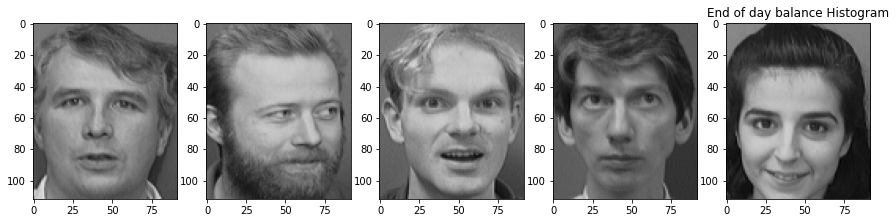

In [0]:
# random Images from data set
plt.figure(figsize=(15,5))

for i in range(5):
  ax1 = plt.subplot(1, 5, i+1)
  plt.imshow(255*X[random.randint(1,len(X))].reshape(height1, width1),cmap='gray', 
             vmin=0, vmax=255)
  
plt.title('End of day balance Histogram')
plt.show()

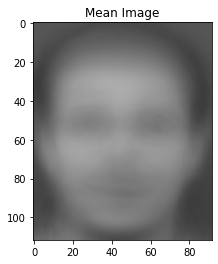

In [0]:
plt.title("Mean Image")
mean_face = np.mean(X,axis=0)
plt.imshow(255*mean_face.reshape(height1, width1),cmap='gray', vmin=0, vmax=255)
plt.show()

In [0]:
zero_centered_faces = X-mean_face
cov_ = np.dot(zero_centered_faces,zero_centered_faces.T) / 400

eig_value,eig_vector = np.linalg.eig(cov_)
eig_vector = eig_vector[:,np.argsort(eig_value)[::-1]]

eig_value = np.sort(eig_value)[::-1]
cum_sum = np.cumsum(eig_value)/np.sum(eig_value)

def no_of_features_required(cum_sum,cov_):
  a = (cum_sum>cov_)*1
  for i in range(len(a)):
    if a[i]==1:
      break
  return i

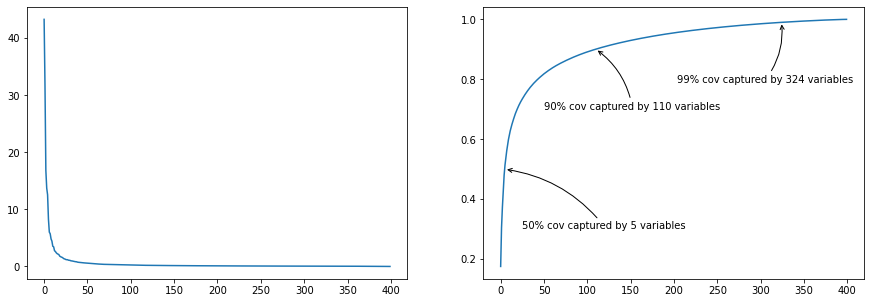

In [0]:
plt.figure(figsize=(15,5))
ax1 = plt.subplot(1, 2, 1)
plt.plot(eig_value)


ax1 = plt.subplot(1, 2, 2)
plt.plot(np.cumsum(eig_value)/np.sum(eig_value))

ax1.annotate('50% cov captured by {} variables'.format(no_of_features_required(cum_sum,0.5)),
            xy=(no_of_features_required(cum_sum,0.5),0.5), 
            xycoords=ax1.transData,
            xytext=(no_of_features_required(cum_sum,0.5)+20,0.5-0.2), 
            textcoords=ax1.transData,
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="arc3,rad=.2"))

ax1.annotate('90% cov captured by {} variables'.format(no_of_features_required(cum_sum,0.9)),
            xy=(no_of_features_required(cum_sum,0.9),0.9),
            xycoords=ax1.transData,
            xytext=(no_of_features_required(cum_sum,0.9)-60,0.9-0.2), 
            textcoords=ax1.transData,
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="arc3,rad=.2"))

ax1.annotate('99% cov captured by {} variables'.format(no_of_features_required(cum_sum,0.99)),
            xy=(no_of_features_required(cum_sum,0.99),0.99), 
            xycoords=ax1.transData,
            xytext=(no_of_features_required(cum_sum,0.99)-120,0.99-0.2), 
            textcoords=ax1.transData,
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="arc3,rad=.2"))
plt.show()

In [0]:
eigen_faces = np.dot(zero_centered_faces.T,eig_vector).T

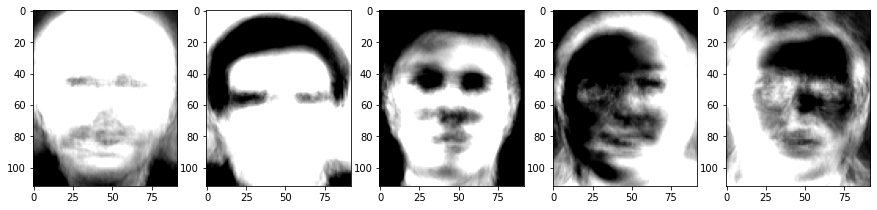

In [0]:
# random Images from data set
plt.figure(figsize=(15,5))
for i in range(5):
  ax1 = plt.subplot(1, 5, i+1)
  plt.imshow((255*(eigen_faces[i]+mean_face)).reshape(height1, width1),cmap='gray', vmin=0, vmax=255)
plt.show()

In [0]:
for i in range(eigen_vectors.shape[0]):
    eigen_faces[i] = eigen_faces[i]/np.linalg.norm(eigen_vectors[i])

reconstructed_face = np.dot(eigen_faces.T,np.dot(eigen_faces,(X[20]-mean_face)))+mean_face

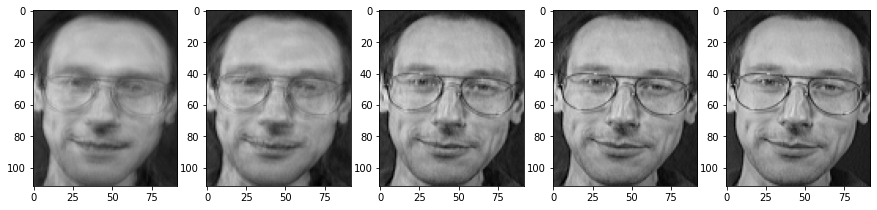

In [0]:
# random Images from data set
k = [50,100,250,300,400]
plt.figure(figsize=(15,5))
face = X[random.randint(1,len(X))]
for i in range(5):
  ax1 = plt.subplot(1, 5, i+1)  
  reconstructed_face = np.dot(eigen_faces[:k[i],:].T,np.dot(eigen_faces[:k[i],:],(face-mean_face)))+mean_face
  plt.imshow(reconstructed_face.reshape(height1, width1),cmap='gray', vmin=0, vmax=1)
plt.show()

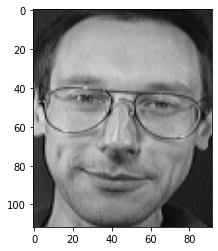

In [0]:
plt.imshow(reconstructed_face.reshape(height1, width1),cmap='gray', vmin=0, vmax=1)